In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth
    
    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }

def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start
    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
         
         return state == self.goal
        
        #raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        
        legal_actions =[]
        for action in MOVES:
             dr,dc = MOVES[action]
             next_state = (state[0]+dr, state[1]+dc)
             if self.in_bounds(next_state) and self.is_free(next_state):
                  legal_actions.append(action)
        return legal_actions 
        # raise NotImplementedError("Complete GridProblem.actions")
    
    
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

        dr, dc = MOVES[action]
        return (state[0] + dr, state[1] +dc)
    
        # raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.

        cost =1
        return cost
        # raise NotImplementedError("Complete GridProblem.action_cost")
    
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s,action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state = s_prime, parent = node, action = action, path_cost = cost)
            
        #raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [6]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].

        row, col = next_state
        return self.terrain_costs[row][col]

        # raise NotImplementedError("Complete WeightedGridProblem.action_cost")

In [8]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [9]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).

    r1, c1 = state
    r2, c2 = goal
    return abs(r1-r2) +abs(c1-c2)
    # raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).

    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1-r2)**2 + (c1-c2)**2)

    # raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [10]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [11]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [12]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.

        node = Node(state=problem.initial_state())

        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)

        reached = {node.state: node}

        nodes_expanded = 0
        max_frontier_size = 1

        while len(frontier) > 0:

            node = frontier.pop()

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if (s not in reached or child.path_cost < reached[s].path_cost):
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            max_frontier_size = max( max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached))
    # raise NotImplementedError("Complete BestFirstSearch.search")

In [13]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        f = self.h(node, problem)
        return f
        # raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

In [14]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
    
        g = node.path_cost
        h = self.h(node, problem)
        return g + h
    # raise NotImplementedError("Complete AStarSearch.evaluation")

In [15]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [16]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        weighted = node.path_cost + self.weight *self.h(node, problem)
        return weighted
        # raise NotImplementedError("Complete WeightedAStarSearch.evaluation")

In [17]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [18]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]
show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


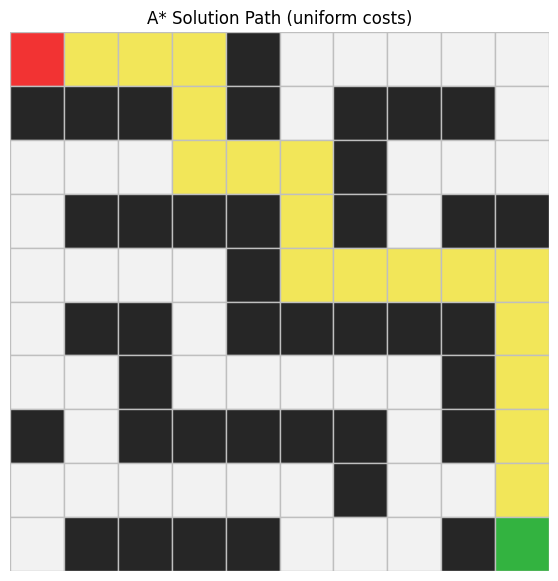

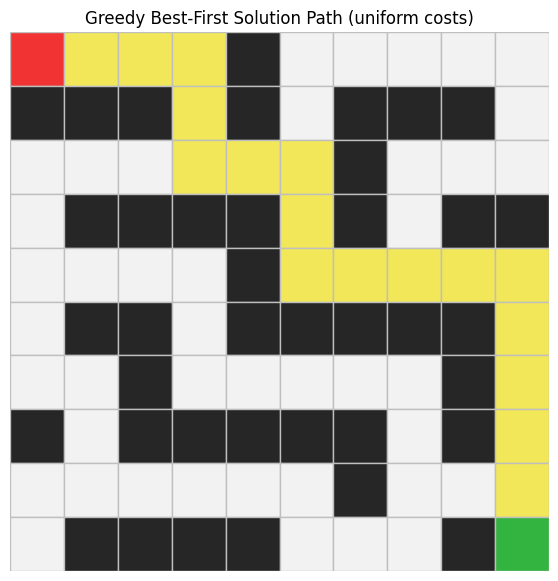

In [19]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)
     

In [20]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


Although Greedy Search expanded only 6 nodes compared to the 25 nodes expanded by A*, it produced a solution with a cost of 30, whereas A* found the optimal solution with a cost of only 10. This demonstrates that expanding fewer nodes does not necessarily make an algorithm better. The quality of the solution is equally important, and in this case A* achieved a much lower-cost path by balancing exploration and optimality, while Greedy sacrificed path quality for speed.

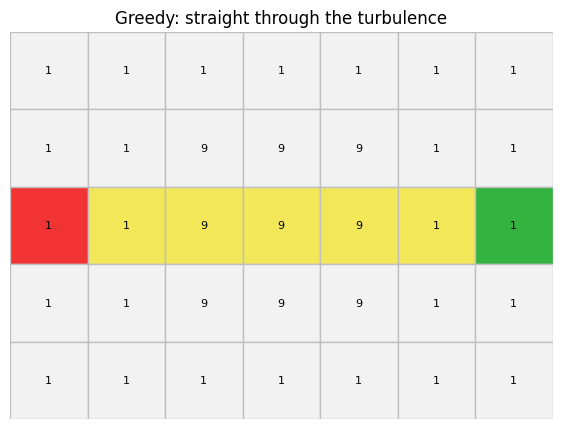

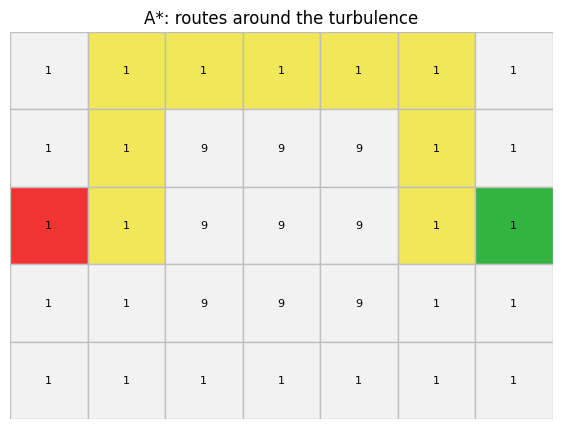

In [21]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [22]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h
    # raise NotImplementedError("Complete inflated_heuristic")


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]
mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


1. On which map(s) did the inflated heuristic return a suboptimal path? By how much?
- The inflated heuristic returned a suboptimal path on the mild turbulence map. The admissible A* on mild turbulence found the optimal solution with a cost of 10, while the inflated heuristic found a solution with a cost of 12. Therefore, the inflated heuristic produced a path that was 2 cost units more expensive than the optimal path. On the uniform map, both algorithms found the same optimal solution cost of 18, so the inflated heuristic was not suboptimal there.
2. How many fewer nodes did it expand?
- On the mild turbulence map, the admissible A* expanded 29 nodes, whereas the inflated heuristic expanded only 6 nodes. Therefore, the inflated heuristic expanded 23 fewer nodes. On the uniform map, both algorithms expanded 18 nodes, so there was no difference.
3. In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?
- when speed is more important than optimality. When getting a fast, good enough path is more valuable than getting the absolute shortest or cheapest path.

In [23]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).

        start = Node(state=problem.initial_state(),
                     path_cost=0)

        def f(node):
            return node.path_cost + self.heuristic(node.state, problem.goal)

        # initial threshold
        limit = f(start)

        nodes_expanded = 0
        max_frontier_size = 0
        iterations = []

        # recursive DFS with f-limit
        def dfs(node, g, limit, path):
            nonlocal nodes_expanded, max_frontier_size

            f_value = g + self.heuristic(node.state, problem.goal)

            if f_value > limit:
                return f_value, None  # cutoff

            if problem.is_goal(node.state):
                return "FOUND", node

            min_threshold = float("inf")
            nodes_expanded += 1

            max_frontier_size = max(max_frontier_size, len(path))

            for child in self.expand(problem, node):
                if child.state in path:
                    continue  # path-cycle check

                path.add(child.state)

                result, solution = dfs(child,
                                       child.path_cost,
                                       limit,
                                       path)

                path.remove(child.state)

                if result == "FOUND":
                    return "FOUND", solution

                if isinstance(result, float):
                    min_threshold = min(min_threshold, result)

            return min_threshold, None

        # main loop
        for _ in range(max_iterations):

            iterations.append((limit, "running"))

            result, solution = dfs(start,
                                   0,
                                   limit,
                                   {start.state})

            if result == "FOUND":
                iterations[-1] = (limit, "success")

                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=solution,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iterations
                )

            if result == float("inf"):
                iterations[-1] = (limit, "failure")

                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iterations
                )

            # update limit
            limit = result
            iterations[-1] = (limit, "cutoff")

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            iterations=iterations
        )
        # raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18,18,5,23
1,IDA*,success,18,18,18,18,0


In [24]:
# TODO 10:
# Create your first custom map here.

# A cheap long way vs expensive short way map: (Weighted by having 1 to 100 costs)
# The direct path is short in moves but extremely expensive. And the optimal path is far. 
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1,  1,  1,  1,  1,  1,  1,  1,  1],
    [1,  1,  1,  1,  1,  1,  1,  1,  1],
    [1,  1, 100, 100, 100, 100, 100,  1,  1],
    [1,  1, 100, 100, 100, 100, 100,  1,  1],
    [1,  1, 100, 100, 100, 100, 100,  1,  1],
    [1,  1, 100, 100, 100, 100, 100,  1,  1],
    [1,  1, 100, 100, 100, 100, 100,  1,  1],
    [1,  1,  1,  1,  1,  1,  1,  1,  1],
    [1,  1,  1,  1,  1,  1,  1,  1,  1],
]

custom_start_1 = (3,0)
custom_goal_1 = (3,8)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,12,12,47,21,68
1,A*,success,12,12,20,23,42
2,Weighted A* (W=2),success,12,12,15,22,37
3,Greedy,success,8,503,8,17,25


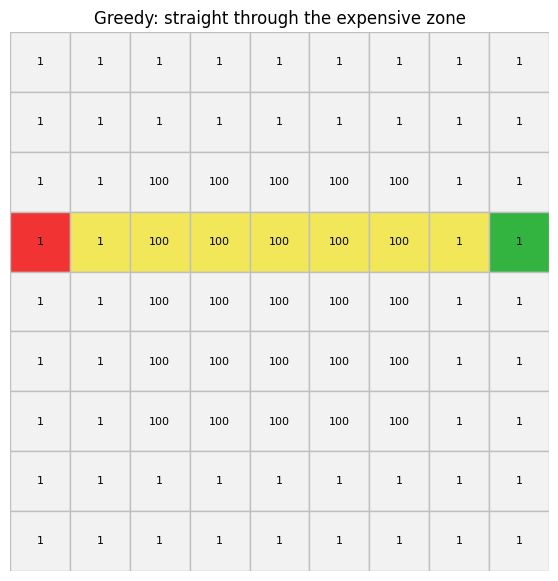

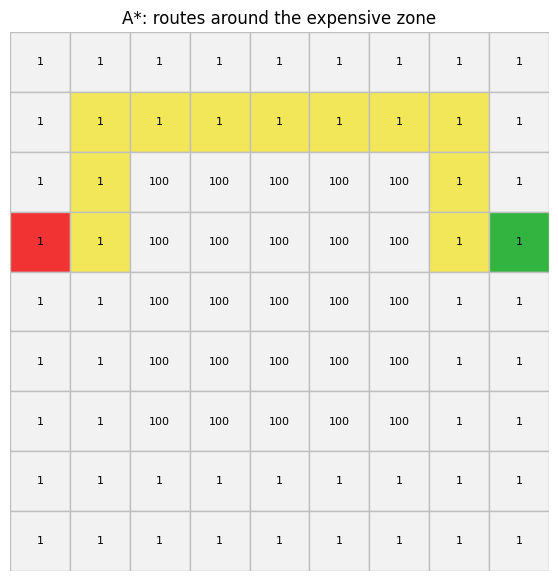

In [25]:
# Visualization for cheap long way vs expensive short way - TODO 10
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="Greedy: straight through the expensive zone",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A*: routes around the expensive zone",
)

In [26]:
# TODO 11:
# Create your second custom map here.

# A larger map: 20 × 20, to make the UCS-vs-A* node-count gap dramatic.
# UCS expand hundreds of nodes vs. A*'s much smaller count for the same optimal solution cost. 

custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,1,0,1,0,1,1,1,1,0,1,1,1,0,1,1,1,0,0],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,1,0,1,1,1,1,0,1,1,1,1,1,0,1,1,0,1,0,0],
    [0,1,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0],
    [0,1,0,1,0,1,1,1,1,0,1,0,1,0,1,0,1,1,0,0],
    [0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0],
    [0,1,1,1,0,1,0,1,1,0,1,0,1,1,1,1,1,0,1,0],
    [0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0],
    [0,1,0,1,1,1,0,1,0,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,1,0,1,1,1,0,1,0,1,1,1,1,1,1,1,0,0],
    [0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    ]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    
]

custom_start_2 = (0,0)
custom_goal_2 = (19,19)


custom_problem_2 = WeightedGridProblem(
    custom_grid_2, 
    custom_start_2, 
    custom_goal_2, 
    terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
   wastar2.search(custom_problem_2),
   greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,38,38,246,13,252
1,A*,success,38,38,145,25,169
2,Weighted A* (W=2),success,38,38,38,23,61
3,Greedy,success,38,38,38,23,61


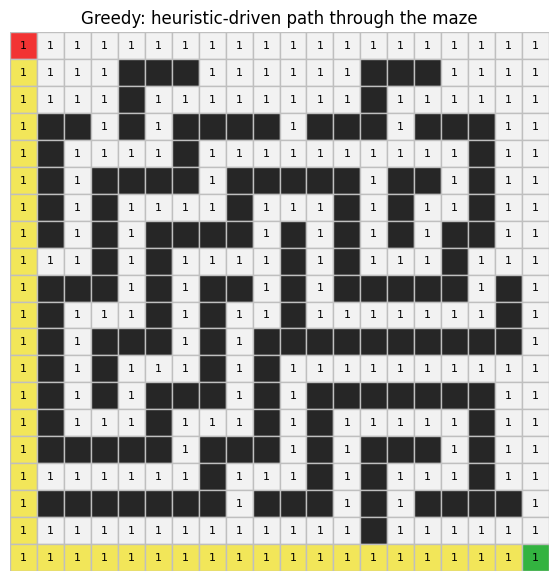

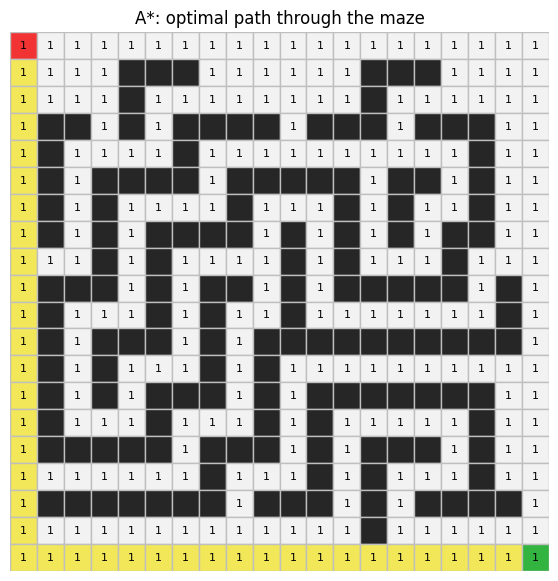

In [27]:
# Visualization for 20x20 maze - TODO 11
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy: heuristic-driven path through the maze",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A*: optimal path through the maze",
)

Reflection Questions

16.1 Heuristic Functions
1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
- h(n) estimates the remaining cost from the current state to the goal. In this lab, its knowledge comes from the coordinates of the current state and goal, using distance measures such as Manhattan or Euclidean distance. 
2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?
- The relaxation removes obstacles, terrain costs greater than 1 and any requirement around blocked cells. This means the drone is moving directly toward the goal as if every cell is free. 
3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?
- Manhattan dominates and is usually largely admissible. Domination predicts that A* with Manhattan distance will expand fewer or equal nodes than A* with Euclidean distance. This is because Manhattan is greater or equal to the Euclidean distance and hence is more informed and lead to the goal. 
4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?
- Manhattan distance counts the minimum number of moves needed. Therefore the true cost can never be smaller than Manhattan distance. If some terrain cost were 0.5, the actual path cost could become smaller than Manhattan distance, causing Manhattan to overestimate and lose admissibility. 


16.2 Greedy Best-First Search
1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
- Greedy ignores g(n) which is the cost already spent reaching the current node. The turbulence map punished Greedy because it expanded states that looked close to the goal while ignoring expensive terrain.
2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?
- Greedy may expand fewer nodes but can return a more expensive path. Beside the speed, the search quality also matters such as the cost. So, A* usually gives the optimal solution. 
3. Describe a drone mission where Greedy's behaviour would actually be acceptable.
- A drone performing a quick visual search after a disaster may value speed over optimality. For a drone mission of reaching the target quickly rather than minimizing path cost, Greedy search would be acceptable.

16.3 A* Search
1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.
- A* compares the cost already flown g(n) and the estimated cost remaining h(n).  It chooses paths that appear cheapest overall.
2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?
- A generated goal node may not represent the cheapest path to the goal. On the turbulence map, A* could generate a goal through expensive terrain before discovering a cheaper route. Waiting until the node is popped ensures it has the lowest available f-value.
3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
- BFS assumes all paths have equal cost, so explored nodes are stored in a set. In this lab, different paths can reach the same state with different costs. The dictionary stores the best-known node for each state so that cheaper paths can replace more expensive ones. 
4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?
- If A* expands significantly fewer nodes than UCS, the heuristic on A*  is giving useful information and guiding the search toward states closer to the goal. 

16.4 Admissibility and Consistency
1. State the definitions of admissible and consistent. Which implies which?
- Admissible: h(n)≤h∗ The heuristic never overestimates the true remaining cost.
- Consistent: h(n)≤c(n,a,n′)+h(n′) for every successor n′ and step cost c. The estimated cost from the current node to the goal is never greater than the cost of moving to a successor plus the estimated cost from that successor to the goal. Therefore, consistency implies admissibility. 
2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
- In A* search, admissible heuristics guarantee that the algorithm will find an optimal solution. An inadmissible heuristic removes this guarantee because it may make some promising paths appear more expensive than they really are( by multiplying the Manhattan distance by a factor greater than 1). As a result, A* may ignore the optimal path and return a suboptimal solution. However, inadmissible heuristics often make the search faster because they are more directing the search toward the goal and typically expand fewer nodes. 
3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.
- Yes. For a single move: c(n,a,n′)=1 and moving one step changes Manhattan distance by at most 1. Therefore: h(n)≤1+h(n′) which satisfies consistency.

16.5 Weighted A* and Trade-offs
1. How does the weight W interpolate between UCS, A*, and Greedy?
- Weighted A*: f(n)=g(n)+W. h(n) 
- W=0 → UCS: the heuristic is ignored completely 
- W=1 → A*: balancing the cost already traveled with the estimated remaining cost. 
- Very large W → behaves increasingly like Greedy: the g(n) term becomes relatively unimportant and the algorithm increasingly behaves like Greedy. 
2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?
- Weighted A* guarantees: solution cost≤W×optimal cost. Although the weighted A* sacrifice optimality, it still keeps finding near-optimal solutions. So, the solution is much closer to the optimal than it’s to the worst-case bound. 
3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?
- I would choose Weighted A* with W=2 because the drone's flight computer is slow, so reducing computation time is important, but the drone still has only a limited battery margin. Using W=1 would guarantee an optimal path but may expand significantly more nodes and take longer to compute. Also, choosing a much larger weight, such as W>2, would make the algorithm behave more like Greedy Best-First Search. This would increase the risk of finding a suboptimal path, which could waste battery power. Therefore, W=2 provides a reasonable balance: it substantially reduces node expansions while usually producing a path that remains close to optimal. 

16.6 Memory and Real-World Drone Context
1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?
- A* stores: the frontier (priority queue), the reached dictionary, all generated nodes. IDA* avoids this by using depth-first search with iterative cost limits. It uses far less memory but performs repeated searches by re-exploring nodes multiple times, increasing computation time.
2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?
- Information such as wind speed, weather forecasts, battery consumption, risk level, no-fly zones, terrain elevation, communication signal strength.
3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?
- If the target moves, previously computed estimates become inaccurate and the current path may no longer be useful. Techniques such as: real-time search, replanning, learned heuristics, dynamic path planning become important.
4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?
- I would deploy A* because it balances efficiency and optimality while providing strong guarantees. However, if memory becomes limited, I would use IDA* because it requires much less memory than A*. If fast decision-making is more important than finding the optimal path, I would use Weighted A* with a moderate weight such as W=2, which reduces search time while usually producing near-optimal solutions. Finally, if the environment changes rapidly or near-optimal routes are acceptable, I would prioritize faster algorithms that sacrifice some optimality in exchange for responsiveness. 